In [ ]:
!pip install facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import random
import shutil
import numpy as np
from tqdm import tqdm
import kagglehub
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

path = kagglehub.dataset_download("reubensuju/celeb-df-v2")
DATA_ROOT = path

BASE_DRIVE = "/content/drive/MyDrive/deepfake_project/data"

FRAME_DIR = os.path.join(BASE_DRIVE, "extracted_frames_celeb_df")
FACE_DIR = os.path.join(BASE_DRIVE, "cropped_faces_celeb_df")

os.makedirs(FRAME_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Using Colab cache for faster access to the 'celeb-df-v2' dataset.


In [ ]:
if os.path.exists(FRAME_DIR):
    shutil.rmtree(FRAME_DIR)

os.makedirs(FRAME_DIR, exist_ok=True)

In [ ]:
real_videos = []
fake_videos = []

for root, _, files in os.walk(os.path.join(DATA_ROOT, "Celeb-real")):
    for f in files:
        if f.endswith(".mp4"):
            real_videos.append(os.path.join(root, f))

for root, _, files in os.walk(os.path.join(DATA_ROOT, "Celeb-synthesis")):
    for f in files:
        if f.endswith(".mp4"):
            fake_videos.append(os.path.join(root, f))

print("Total real:", len(real_videos))
print("Total fake:", len(fake_videos))

Total real: 590
Total fake: 5639


In [ ]:
random.seed(42)

real_selected = random.sample(real_videos, 300)
fake_selected = random.sample(fake_videos, 300)

In [ ]:
def get_video_id(video_path):
    return (
        video_path.replace(DATA_ROOT, "")
        .replace("/", "_")
        .replace(".mp4", "")
    )

In [ ]:
def extract_frames(video_path, output_dir, frame_skip=5):

    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("[ERROR] Cannot open:", video_path)
        return

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_skip == 0:
            frame_path = os.path.join(
                output_dir,
                f"frame_{saved_count:05d}.jpg"
            )
            cv2.imwrite(frame_path, frame)
            saved_count += 1

        frame_count += 1

    cap.release()

    print(f"[DONE] {get_video_id(video_path)} -> {saved_count} frames")

In [ ]:
import os

path = "/content/drive/MyDrive/deepfake_project/data/extracted_frames_celeb_df"

if not os.path.exists(path):
    print("Folder does NOT exist")
else:
    # list everything inside (including subfolders/files)
    contents = os.listdir(path)

    if len(contents) == 0:
        print("Folder exists but is EMPTY")
    else:
        print("Folder is NOT empty")
        print("Contents:", contents[:10])  # show first 10 items

Folder exists but is EMPTY


In [ ]:
print("Extracting frames...")

all_videos = (
    [(v, "real") for v in real_selected] +
    [(v, "fake") for v in fake_selected]
)

for video_path, label in tqdm(all_videos):

    video_id = get_video_id(video_path)

    save_dir = os.path.join(FRAME_DIR, label, video_id)

    extract_frames(
        video_path,
        save_dir,
        frame_skip=5
    )

Extracting frames...


  0%|          | 1/600 [00:01<16:39,  1.67s/it]

[DONE] _Celeb-real_id4_0003 -> 89 frames


  0%|          | 2/600 [00:02<12:25,  1.25s/it]

[DONE] _Celeb-real_id17_0009 -> 60 frames


...

[DONE] _Celeb-synthesis_id19_id23_0001 -> 67 frames


100%|█████████▉| 599/600 [15:08<00:01,  1.44s/it]

[DONE] _Celeb-synthesis_id49_id56_0006 -> 66 frames


100%|██████████| 600/600 [15:09<00:00,  1.52s/it]

[DONE] _Celeb-synthesis_id49_id56_0004 -> 83 frames


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from facenet_pytorch import MTCNN
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mtcnn = MTCNN(
    image_size=224,
    margin=20,
    device=device,
    keep_all=False
)

MAX_FRAMES_PER_VIDEO = 30
FRAME_SKIP = 3

In [ ]:
def crop_face(image_path, save_path):

    if os.path.exists(save_path):
        return True

    try:
        img = cv2.imread(image_path)
        if img is None:
            return False

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        face = mtcnn(img_rgb)

        if face is None:
            return False

        face = face.permute(1, 2, 0).detach().cpu().numpy()
        face = ((face + 1) / 2 * 255).astype(np.uint8)

        face_bgr = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)

        cv2.imwrite(save_path, face_bgr)

        return True

    except:
        return False

Testing face cropping function with one image

In [ ]:
import os

# Example: pick one frame manually from extracted dataset
test_frame_path = "/content/drive/MyDrive/deepfake_project/data/extracted_frames_celeb_df/real/_Celeb-real_id0_0005/frame_00000.jpg"

print("Exists:", os.path.exists(test_frame_path))

Exists: True


In [ ]:
test_out_path = "/content/drive/MyDrive/deepfake_project/data/test_face.jpg"

In [ ]:
result = crop_face(test_frame_path, test_out_path)

print("Crop success:", result)

Crop success: True


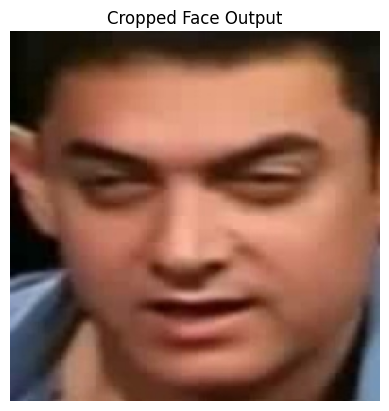

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(test_out_path)

if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.title("Cropped Face Output")
    plt.show()
else:
    print("No output image generated (face may not be detected)")

In [ ]:
frame_root = FRAME_DIR   # extracted_frames_celeb_df
face_root = FACE_DIR     # cropped_faces_celeb_df

for split in ["real", "fake"]:

    split_dir = os.path.join(frame_root, split)

    if not os.path.exists(split_dir):
        print(f"[SKIP] Missing folder: {split}")
        continue

    videos = os.listdir(split_dir)

    for video in tqdm(videos, desc=f"Cropping {split}"):

        video_dir = os.path.join(split_dir, video)

        if not os.path.isdir(video_dir):
            continue

        out_dir = os.path.join(face_root, split, video)
        os.makedirs(out_dir, exist_ok=True)

        frames = sorted(os.listdir(video_dir))

        saved = 0

        for i, frame_name in enumerate(frames):

            if i % FRAME_SKIP != 0:
                continue

            if saved >= MAX_FRAMES_PER_VIDEO:
                break

            frame_path = os.path.join(video_dir, frame_name)
            save_path  = os.path.join(out_dir, frame_name)

            if crop_face(frame_path, save_path):
                saved += 1

        print(f"[DONE] {split}/{video} -> {saved} faces")

Cropping real:   0%|          | 1/300 [00:03<15:06,  3.03s/it]

[DONE] real/_Celeb-real_id4_0003 -> 30 faces


Cropping real:   1%|          | 2/300 [00:05<12:55,  2.60s/it]

[DONE] real/_Celeb-real_id17_0009 -> 20 faces


Cropping real:   1%|          | 3/300 [00:07<12:35,  2.54s/it]

...

[DONE] fake/_Celeb-synthesis_id19_id23_0001 -> 23 faces


Cropping fake: 100%|█████████▉| 299/300 [15:26<00:03,  3.23s/it]

[DONE] fake/_Celeb-synthesis_id49_id56_0006 -> 22 faces


Cropping fake: 100%|██████████| 300/300 [15:30<00:00,  3.10s/it]

[DONE] fake/_Celeb-synthesis_id49_id56_0004 -> 28 faces


In [ ]:
import os

path = "/content/drive/MyDrive/deepfake_project/data/cropped_faces_celeb_df"

if not os.path.exists(path):
    print("Folder does NOT exist")
else:
    # list everything inside (including subfolders/files)
    contents = os.listdir(path)

    if len(contents) == 0:
        print("Folder exists but is EMPTY")
    else:
        print("Folder is NOT empty")
        print("Contents:", contents[:10])  # show first 10 items

Folder is NOT empty
Contents: ['real', 'fake']


In [ ]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/deepfake_project/data/cropped_faces_celeb_df"

rows = []

for label_name, label in [("real", 0), ("fake", 1)]:

    split_dir = os.path.join(BASE_PATH, label_name)

    if not os.path.exists(split_dir):
        continue

    for video_id in os.listdir(split_dir):

        video_dir = os.path.join(split_dir, video_id)

        if not os.path.isdir(video_dir):
            continue

        for frame in os.listdir(video_dir):

            if not frame.endswith(".jpg"):
                continue

            frame_path = os.path.join(video_dir, frame)

            rows.append({
                "frame_path": frame_path,
                "video_id": video_id,
                "label": label
            })

df = pd.DataFrame(rows)

csv_path = "/content/drive/MyDrive/deepfake_project/data/metadata/frame_metadata_celeb_df.csv"
df.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print(df.head())
print("Total frames:", len(df))

Saved: /content/drive/MyDrive/deepfake_project/data/metadata/frame_metadata_celeb_df.csv
                                          frame_path              video_id  \
0  /content/drive/MyDrive/deepfake_project/data/c...  _Celeb-real_id4_0003   
1  /content/drive/MyDrive/deepfake_project/data/c...  _Celeb-real_id4_0003   
2  /content/drive/MyDrive/deepfake_project/data/c...  _Celeb-real_id4_0003   
3  /content/drive/MyDrive/deepfake_project/data/c...  _Celeb-real_id4_0003   
4  /content/drive/MyDrive/deepfake_project/data/c...  _Celeb-real_id4_0003   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  
Total frames: 14971


In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import cv2
from collections import defaultdict
import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "tf_efficientnetv2_b0",
    pretrained=False,
    num_classes=1
)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/deepfake_project/best_model.pth",
    map_location=device
))

model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
    )
    (1): Sequential(
      (0): EdgeResidual(
        (conv_exp): Conv2dSame(16, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (bn1): BatchNormAct2d(
          64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity(

In [ ]:
class FrameDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row["frame_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))

        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        label = torch.tensor(row["label"], dtype=torch.float32)

        return img, label, row["video_id"]

In [ ]:
csv_path = "/content/drive/MyDrive/deepfake_project/data/metadata/frame_metadata_celeb_df.csv"

df = pd.read_csv(csv_path)

dataset = FrameDataset(df)

loader = DataLoader(dataset, batch_size=32, shuffle=False)

In [ ]:
sigmoid = torch.nn.Sigmoid()

video_probs = defaultdict(list)
video_labels = {}

In [ ]:
with torch.no_grad():
    for imgs, labels, video_ids in loader:

        imgs = imgs.to(device)

        logits = model(imgs).squeeze(1)
        probs = sigmoid(logits).cpu().numpy()

        labels = labels.numpy()

        for p, y, vid in zip(probs, labels, video_ids):
            video_probs[vid].append(p)
            video_labels[vid] = y

In [ ]:
video_preds = []
video_trues = []

for vid in video_probs:

    avg_prob = np.mean(video_probs[vid])
    pred = 1 if avg_prob > 0.5 else 0

    video_preds.append(pred)
    video_trues.append(video_labels[vid])

In [ ]:
print("\n=== CELEB-DF VIDEO LEVEL RESULTS ===")

print("Accuracy :", accuracy_score(video_trues, video_preds))
print("Precision:", precision_score(video_trues, video_preds))
print("Recall   :", recall_score(video_trues, video_preds))
print("F1 Score :", f1_score(video_trues, video_preds))

# AUC using video probabilities
video_avg_probs = [
    np.mean(video_probs[vid]) for vid in video_probs
]

print("ROC-AUC  :", roc_auc_score(video_trues, video_avg_probs))


=== CELEB-DF VIDEO LEVEL RESULTS ===
Accuracy : 0.5
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5507777777777778


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
all_probs = []

for vid in video_probs:
    all_probs.extend(video_probs[vid])

print("Min:", np.min(all_probs))
print("Max:", np.max(all_probs))
print("Mean:", np.mean(all_probs))

Min: 3.475408e-12
Max: 0.941148
Mean: 0.013987506


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# =========================
# METHOD A: TOP-K PREDICTION
# =========================

video_preds_topk = []
video_trues_topk = []

for vid in video_probs:

    probs = np.array(video_probs[vid])

    k = max(1, int(len(probs) * 0.1))  # top 10%

    top_k_mean = np.mean(np.sort(probs)[-k:])

    pred = 1 if top_k_mean > 0.5 else 0

    video_preds_topk.append(pred)
    video_trues_topk.append(video_labels[vid])


print("\n=== CELEB-DF VIDEO LEVEL RESULTS (TOP-K) ===")

print("Accuracy :", accuracy_score(video_trues_topk, video_preds_topk))
print("Precision:", precision_score(video_trues_topk, video_preds_topk))
print("Recall   :", recall_score(video_trues_topk, video_preds_topk))
print("F1 Score :", f1_score(video_trues_topk, video_preds_topk))


=== CELEB-DF VIDEO LEVEL RESULTS (TOP-K) ===
Accuracy : 0.49333333333333335
Precision: 0.3
Recall   : 0.01
F1 Score : 0.01935483870967742


In [ ]:
video_probs_topk_score = []

for vid in video_probs:

    probs = np.array(video_probs[vid])

    k = max(1, int(len(probs) * 0.1))

    top_k_mean = np.mean(np.sort(probs)[-k:])

    video_probs_topk_score.append(top_k_mean)


print("ROC-AUC  :", roc_auc_score(video_trues_topk, video_probs_topk_score))

ROC-AUC  : 0.5337666666666666
